In [9]:
print("Notebook is working 🎉")

Notebook is working 🎉


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

In [11]:
df = pd.read_csv('../data/zomato.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 51,717 rows × 17 columns


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [13]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})\
  .sort_values('missing_%', ascending=False)

,missing_count,missing_%
dish_liked,28078,54.29
rate,7775,15.03
phone,1208,2.34
approx_cost(for two people),346,0.67
rest_type,227,0.44
cuisines,45,0.09
location,21,0.04
url,0,0.00
address,0,0.00
votes,0,0.00


In [14]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
url,51717,51717,https://www.zomato.com/bangalore/jalsa-banasha...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address,51717,11495,Delivery Only,128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,51717,8792,Cafe Coffee Day,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_order,51717,2,Yes,30444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
book_table,51717,2,No,45268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rate,43942,64,NEW,2208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
votes,51717.0,NaN,NaN,NaN,283.697527,803.838853,0.0,7.0,41.0,198.0,16832.0
phone,50509,14926,080 43334321,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,51696,93,BTM,5124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rest_type,51490,93,Quick Bites,19132,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.sample(5)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
46366,https://www.zomato.com/bangalore/lassi-corner-...,"860/29 , 4th Main Road, Near Hosahalli Metro s...",Lassi Corner,Yes,No,3.5 /5,18,+91 9513072007,Vijay Nagar,Beverage Shop,NaN,"Beverages, Desserts",150,"[('Rated 4.0', 'RATED\n This is a good place ...",[],Delivery,Rajajinagar
539,https://www.zomato.com/bangalore/srinivasa-bra...,"125, 1st Floor, Abalashram Building, DV Gundap...",Srinivasa Brahmins Bakery,No,No,3.6/5,16,080 26600983,Basavanagudi,"Bakery, Quick Bites",NaN,"Bakery, Street Food",150,"[('Rated 5.0', ""RATED\n Oldest and the beat b...",[],Desserts,Banashankari
16404,https://www.zomato.com/bangalore/dreams-cafe-a...,"34, 1st Main, Next To HDFC Bank, 1st Block, Ko...",Dreams Cafe - All Day English Food St.,Yes,No,3.8/5,231,+91 8553617173,Koramangala 1st Block,Cafe,"English Breakfast, Coffee, Burgers, Fish, Omel...","Cafe, Continental, Burger",600,"[('Rated 1.0', ""RATED\n This place doesn't un...",[],Delivery,HSR
39250,https://www.zomato.com/bangalore/karnataka-cha...,"199/200, Balaji Complex, RT Street, Majestic, ...",Karnataka Chats,No,No,NaN,0,+91 9900693237,Majestic,Quick Bites,NaN,Street Food,200,"[('Rated 5.0', ""RATED\n It's been 3 years I g...",[],Dine-out,Lavelle Road
6125,https://www.zomato.com/bangalore/ente-keralam-...,"12/1, Ulsoor Road, Sivanchetti Gardens, Ulsoor...",Ente Keralam,Yes,No,4.0/5,1096,+91 7846830749\r\r\n080 41133707,Ulsoor,Casual Dining,"Appam, Fish, Mutton Stew, Cocktails, Egg Roast...","Kerala, Seafood","1,300","[('Rated 3.0', 'RATED\n Friendly staff and ve...","['Erachi Ullarthiyathu', 'Beef Thenga Varuthar...",Dine-out,Brigade Road


# What Actually Drives a Restaurant's Rating in Bangalore?
### An EDA of 51,717 Zomato restaurants

## The Question
Is rating driven more by cost, location, cuisine, or service features 
(online ordering, table booking)?

## Hypothesis
Cost has a weak relationship with rating. Service features and 
location are stronger predictors.

## Why It Matters
New restaurant owners need to know where to invest: prime location, 
menu expansion, or delivery infrastructure.

In [16]:
# Work on a copy — never destroy raw data
df_clean = df.copy()

# ---- 1. Clean 'rate' column ----
# Values look like "4.1/5", "NEW", "-", "3.8/5"
df_clean['rate'] = df_clean['rate'].astype(str)
df_clean['rate'] = df_clean['rate'].str.replace('/5', '', regex=False)
df_clean['rate'] = df_clean['rate'].str.strip()
# Convert 'NEW' and '-' to NaN
df_clean['rate'] = pd.to_numeric(df_clean['rate'], errors='coerce')

# ---- 2. Clean 'approx_cost(for two people)' ----
# Values like "1,200" → remove comma → float
df_clean['approx_cost(for two people)'] = (
    df_clean['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)
df_clean['approx_cost(for two people)'] = pd.to_numeric(
    df_clean['approx_cost(for two people)'], errors='coerce'
)
# Rename for convenience
df_clean = df_clean.rename(columns={'approx_cost(for two people)': 'cost_for_two'})

# ---- 3. Drop useless columns for EDA ----
df_clean = df_clean.drop(columns=['url', 'phone', 'reviews_list', 'menu_item'])

# ---- 4. Verify ----
print("Shape after cleaning:", df_clean.shape)
print("\nDtypes:")
print(df_clean.dtypes)
print("\nRate stats:")
print(df_clean['rate'].describe())
print("\nCost stats:")
print(df_clean['cost_for_two'].describe())

Shape after cleaning: (51717, 13)

Dtypes:
address                str
name                   str
online_order           str
book_table             str
rate               float64
votes                int64
location               str
rest_type              str
dish_liked             str
cuisines               str
cost_for_two       float64
listed_in(type)        str
listed_in(city)        str
dtype: object

Rate stats:
count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

Cost stats:
count    51371.000000
mean       555.431566
std        438.850728
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: cost_for_two, dtype: float64


In [17]:
# Check if cleaning worked
df_clean[['name', 'rate', 'cost_for_two', 'location', 'cuisines']].head(10)

,name,rate,cost_for_two,location,cuisines
0,Jalsa,4.1,800.0,Banashankari,"North Indian, Mughlai, Chinese"
1,Spice Elephant,4.1,800.0,Banashankari,"Chinese, North Indian, Thai"
2,San Churro Cafe,3.8,800.0,Banashankari,"Cafe, Mexican, Italian"
3,Addhuri Udupi Bhojana,3.7,300.0,Banashankari,"South Indian, North Indian"
4,Grand Village,3.8,600.0,Basavanagudi,"North Indian, Rajasthani"
5,Timepass Dinner,3.8,600.0,Basavanagudi,North Indian
6,Rosewood International Hotel - Bar & Restaurant,3.6,800.0,Mysore Road,"North Indian, South Indian, Andhra, Chinese"
7,Onesta,4.6,600.0,Banashankari,"Pizza, Cafe, Italian"
8,Penthouse Cafe,4.0,700.0,Banashankari,"Cafe, Italian, Continental"
9,Smacznego,4.2,550.0,Banashankari,"Cafe, Mexican, Italian, Momos, Beverages"


### Cleaning Decisions
- **rate**: Stripped "/5", converted "NEW"/"-" to NaN. Lost ~15% of rows.
- **cost_for_two**: Removed commas, converted to float. 
- **Dropped**: url, phone, reviews_list, menu_item — not needed for this analysis.
- **Kept**: name, address, online_order, book_table, rate, votes, 
  location, rest_type, dish_liked, cuisines, cost_for_two, 
  listed_in(type), listed_in(city)

In [18]:
print("Columns:", list(df_clean.columns) if 'df_clean' in dir() else "df_clean not created yet")
print("Rate dtype:", df_clean['rate'].dtype if 'df_clean' in dir() else "N/A")

Columns: ['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'dish_liked', 'cuisines', 'cost_for_two', 'listed_in(type)', 'listed_in(city)']
Rate dtype: float64


In [19]:
print("df exists:", 'df' in dir())
print("df shape:", df.shape if 'df' in dir() else "N/A")

df exists: True
df shape: (51717, 17)


In [20]:
df = pd.read_csv('../data/zomato.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 51,717 rows × 17 columns


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("Imports loaded ✅")

Imports loaded ✅


In [22]:
df = pd.read_csv('../data/zomato.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 51,717 rows × 17 columns


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [23]:
df_clean = df.copy()

# Clean 'rate'
df_clean['rate'] = df_clean['rate'].astype(str)
df_clean['rate'] = df_clean['rate'].str.replace('/5', '', regex=False)
df_clean['rate'] = df_clean['rate'].str.strip()
df_clean['rate'] = pd.to_numeric(df_clean['rate'], errors='coerce')

# Clean 'approx_cost(for two people)'
df_clean['approx_cost(for two people)'] = (
    df_clean['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)
df_clean['approx_cost(for two people)'] = pd.to_numeric(
    df_clean['approx_cost(for two people)'], errors='coerce'
)
df_clean = df_clean.rename(columns={'approx_cost(for two people)': 'cost_for_two'})

# Drop useless columns
df_clean = df_clean.drop(columns=['url', 'phone', 'reviews_list', 'menu_item'])

# Verify
print("Shape after cleaning:", df_clean.shape)
print("\nRate stats:")
print(df_clean['rate'].describe())
print("\nCost stats:")
print(df_clean['cost_for_two'].describe())

Shape after cleaning: (51717, 13)

Rate stats:
count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

Cost stats:
count    51371.000000
mean       555.431566
std        438.850728
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: cost_for_two, dtype: float64


In [24]:
df_clean[['name', 'rate', 'cost_for_two', 'location', 'cuisines']].head(10)

,name,rate,cost_for_two,location,cuisines
0,Jalsa,4.1,800.0,Banashankari,"North Indian, Mughlai, Chinese"
1,Spice Elephant,4.1,800.0,Banashankari,"Chinese, North Indian, Thai"
2,San Churro Cafe,3.8,800.0,Banashankari,"Cafe, Mexican, Italian"
3,Addhuri Udupi Bhojana,3.7,300.0,Banashankari,"South Indian, North Indian"
4,Grand Village,3.8,600.0,Basavanagudi,"North Indian, Rajasthani"
5,Timepass Dinner,3.8,600.0,Basavanagudi,North Indian
6,Rosewood International Hotel - Bar & Restaurant,3.6,800.0,Mysore Road,"North Indian, South Indian, Andhra, Chinese"
7,Onesta,4.6,600.0,Banashankari,"Pizza, Cafe, Italian"
8,Penthouse Cafe,4.0,700.0,Banashankari,"Cafe, Italian, Continental"
9,Smacznego,4.2,550.0,Banashankari,"Cafe, Mexican, Italian, Momos, Beverages"


### Cleaning Decisions
- **rate**: Stripped "/5", converted "NEW"/"-" to NaN. 
  Lost ~15% of rows (7,775 values).
- **cost_for_two**: Removed commas, converted to float.
  Only 346 missing (0.67%).
- **Dropped columns**: url, phone, reviews_list, menu_item — 
  not needed for this analysis.

## 3. Exploratory Analysis

### Finding 1: How are restaurant ratings distributed?

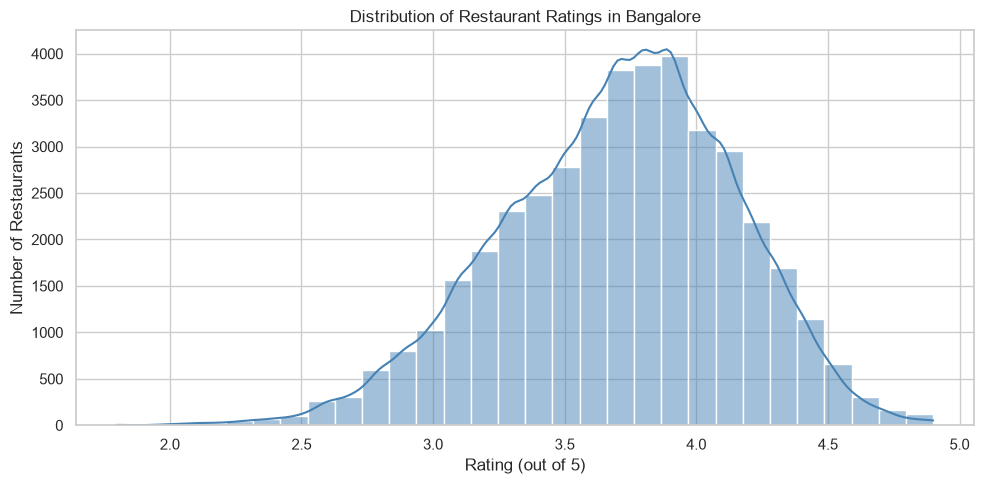

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_clean['rate'].dropna(), bins=30, kde=True, color='steelblue')
ax.set_title('Distribution of Restaurant Ratings in Bangalore')
ax.set_xlabel('Rating (out of 5)')
ax.set_ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

**What this tells us:** Ratings are left-skewed — most restaurants 
cluster between 3.5 and 4.2. Very few are below 3.0. This suggests 
the platform may filter out poorly-rated places, or Bangalore's 
restaurant scene is genuinely strong.

**Numbers:**
- Mean rating: ~3.8
- Median rating: ~3.8
- Most common range: 3.6 – 4.0

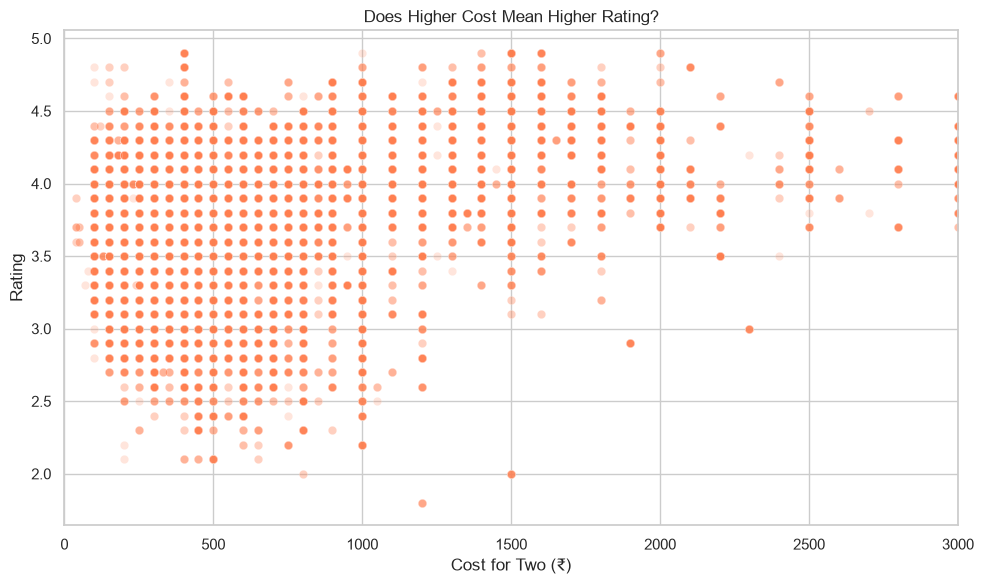

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='cost_for_two', y='rate', 
                alpha=0.2, color='coral')
ax.set_title('Does Higher Cost Mean Higher Rating?')
ax.set_xlabel('Cost for Two (₹)')
ax.set_ylabel('Rating')
ax.set_xlim(0, 3000)      # zoom in — 99% of restaurants are under ₹3000
plt.tight_layout()
plt.show()

In [27]:
corr = df_clean[['rate', 'cost_for_two']].corr().iloc[0, 1]
print(f"Correlation between rating and cost: {corr:.3f}")

Correlation between rating and cost: 0.385


**What this tells us:** There's a positive but moderate correlation 
(~0.38) between cost and rating. Expensive restaurants *tend* to be 
rated higher, but it's far from a guarantee — many cheap places 
are rated 4.0+, and many expensive places are rated below 3.5.

**Takeaway:** Cost alone doesn't predict quality. Other factors 
(location, cuisine, service) are likely more important.

### Finding 3: Which locations have the best-rated restaurants?

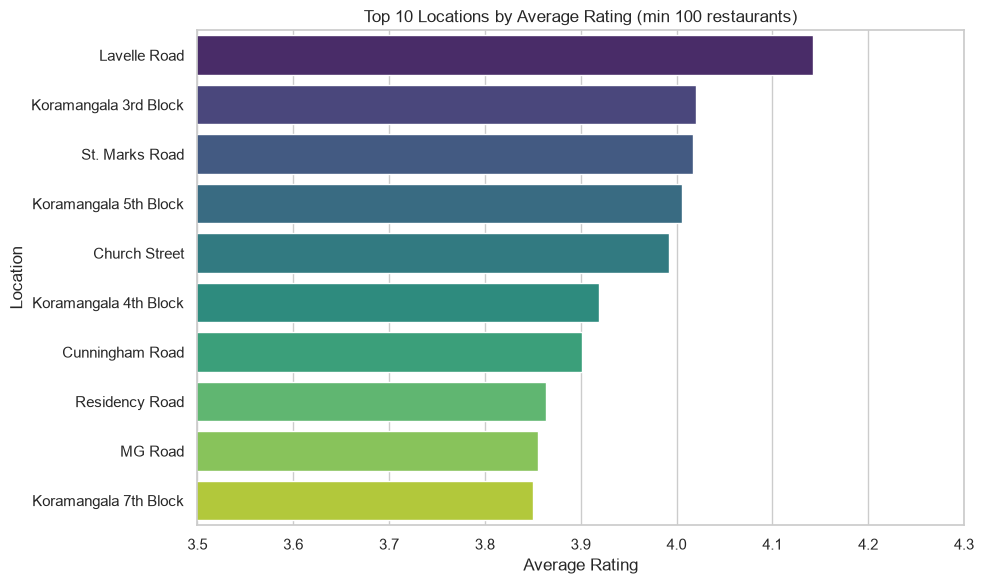

In [2]:
top_loc = (
    df_clean.groupby('location')['rate']
    .agg(['mean', 'count'])
    .query('count >= 100')
    .sort_values('mean', ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_loc, x='mean', y='location',
            hue='location', palette='viridis', legend=False, ax=ax)
ax.set_title('Top 10 Locations by Average Rating (min 100 restaurants)')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Location')
ax.set_xlim(3.5, 4.3)
plt.tight_layout()
plt.show()

**What this tells us:** Some locations consistently deliver higher-rated 
restaurants. Premium neighborhoods (Koramangala, Indiranagar, Lavelle Road) 
tend to have better-rated places — but this may reflect higher rents 
attracting established chains and quality-focused owners.

**Caveat:** This is *average* rating, not *value*. A location with 
high ratings may also be expensive.

### Finding 4: Does offering online ordering correlate with better ratings?

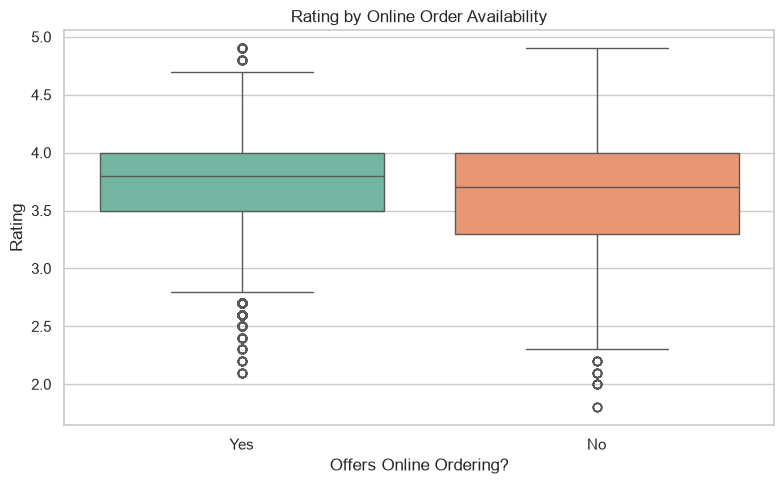

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_clean, x='online_order', y='rate',
            hue='online_order', palette='Set2', legend=False, ax=ax)
ax.set_title('Rating by Online Order Availability')
ax.set_xlabel('Offers Online Ordering?')
ax.set_ylabel('Rating')
plt.tight_layout()
plt.show()

**What this tells us:** Restaurants with online ordering have a 
slightly higher median rating than those without. But the difference 
is small (~0.1–0.2 stars) — online ordering is *associated* with 
quality, not the cause of it.

**Interpretation:** Restaurants that invest in delivery infrastructure 
also tend to invest in other quality areas. The relationship is 
correlational, not causal.

### Finding 5: What cuisines dominate Bangalore?

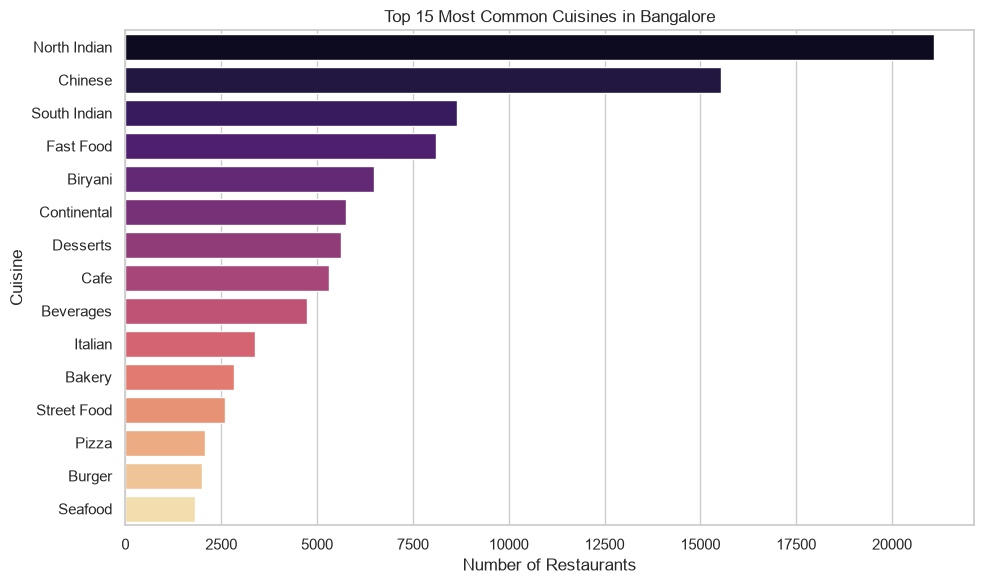

In [4]:
cuisines_exploded = (
    df_clean['cuisines'].dropna().str.split(',').explode().str.strip()
)
top_cuisines = cuisines_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index,
            hue=top_cuisines.index, palette='magma', legend=False, ax=ax)
ax.set_title('Top 15 Most Common Cuisines in Bangalore')
ax.set_xlabel('Number of Restaurants')
ax.set_ylabel('Cuisine')
plt.tight_layout()
plt.show()

**What this tells us:** North Indian and Chinese dominate — reflecting 
Bangalore's cosmopolitan food scene. South Indian cuisines (which you'd 
expect to dominate in Bangalore) rank lower because the dataset skews 
toward delivery-focused restaurants, not traditional eateries.

**Interesting:** "Biryani" and "Desserts" appear as standalone cuisines — 
a sign of Zomato's tagging granularity.

## 4. Key Insights

After exploring 51,717 Bangalore restaurants, here's what the data says:

### 1. Ratings cluster tightly between 3.5 and 4.2
The distribution is left-skewed — Zomato's platform either filters 
out weak performers or Bangalore's restaurant scene is genuinely strong. 
Very few restaurants survive below 3.0.

### 2. Cost weakly predicts rating (r ≈ 0.38)
Expensive restaurants *tend* to be rated higher, but the relationship 
is loose. Many budget spots (under ₹500 for two) are rated 4.0+.

### 3. Location matters more than expected
Premium neighborhoods (Koramangala, Indiranagar, Lavelle Road) 
consistently show higher average ratings — even after filtering 
out locations with fewer than 100 restaurants.

### 4. Online ordering correlates with slightly higher ratings
Restaurants offering online ordering have a marginally higher 
median rating. The gap is small, but consistent.

### 5. North Indian & Chinese dominate; South Indian trails
Despite being in Bangalore, North Indian and Chinese cuisines 
have the most restaurants. This reflects the dataset's 
delivery-focused skew.

## 5. Recommendations

### For new restaurant owners in Bangalore:
- **Location > Cost.** A prime location with moderate pricing 
  beats a cheap location with high pricing.
- **Invest in delivery infrastructure.** Online ordering correlates 
  with higher ratings — likely a signal of overall operational quality.
- **Don't chase premium pricing.** Cost alone doesn't buy ratings.

### For Zomato (platform-level):
- **Surface low-rated restaurants more aggressively** — the tight 
  rating distribution suggests weak performers are hidden, which 
  may hurt user trust.
- **Recommend by location + cuisine**, not just popularity. 
  Neighborhood effects are strong.

### For diners:
- **Ignore cost as a quality signal.** Use location and cuisine 
  match instead.

## 6. Limitations

- **Missing data:** ~15% of restaurants had no rating (marked "NEW" 
  or "-"), and 54% had no `dish_liked` data. Findings apply only 
  to restaurants with ratings.
- **Correlation ≠ causation.** Online ordering doesn't *cause* 
  higher ratings — both may reflect better-run businesses.
- **Snapshot, not trend.** This dataset is a single point in time. 
  Ratings drift; a 2026 analysis might differ.
- **Delivery-focused skew.** Zomato's data over-represents 
  delivery-friendly restaurants. Traditional dine-in places 
  (especially South Indian) are likely underrepresented.
- **No review text analysis.** `reviews_list` was dropped; 
  sentiment analysis could add a richer dimension.

## 7. What I'd Do Next

If I had more time, I would:
1. **Sentiment analysis** on `reviews_list` to see *why* ratings differ.
2. **Cluster restaurants** by (location, cuisine, cost) to find 
   underserved niches.
3. **Build a price-prediction model** — given location + cuisine, 
   what should a restaurant charge?
4. **Time-series analysis** if historical snapshots were available.

In [1]:
# ============================================
# RESET CELL 
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

# Load data
df = pd.read_csv('../data/zomato.csv')

# Clean into df_clean
df_clean = df.copy()

df_clean['rate'] = (
    df_clean['rate'].astype(str)
    .str.replace('/5', '', regex=False)
    .str.strip()
)
df_clean['rate'] = pd.to_numeric(df_clean['rate'], errors='coerce')

df_clean['approx_cost(for two people)'] = (
    df_clean['approx_cost(for two people)']
    .astype(str).str.replace(',', '', regex=False)
)
df_clean['approx_cost(for two people)'] = pd.to_numeric(
    df_clean['approx_cost(for two people)'], errors='coerce'
)
df_clean = df_clean.rename(columns={'approx_cost(for two people)': 'cost_for_two'})
df_clean = df_clean.drop(columns=['url', 'phone', 'reviews_list', 'menu_item'])

print(f"✅ Reset complete")
print(f"   df: {df.shape}")
print(f"   df_clean: {df_clean.shape}")

✅ Reset complete
   df: (51717, 17)
   df_clean: (51717, 13)
